# Simulating Losses — Portfolio

Two-step analysis of `data/portfolio_simulation.csv`:

**Step 1 — Asset correlation** per exposure using the Basel simplified corporate formula:
$$\rho_i = 0.12 + 0.12 \cdot e^{-50 \cdot PD_i}$$

**Step 2 — Analytical tail-loss approximation** (Gordy, 2003). Under the asymptotic homogeneous portfolio approximation the portfolio loss quantile at confidence level $q$ is:
$$L_q \approx \sum_{i=1}^{n} \text{EAD}_i \cdot \text{LGD} \cdot \Phi\!\left(\frac{\Phi^{-1}(PD_i) + \sqrt{\rho_i}\,\Phi^{-1}(q)}{\sqrt{1-\rho_i}}\right)$$

Assumptions: **LGD = 40 %**, confidence levels evaluated at 99 %, 99.9 % (Basel), and 99.97 %.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sys, pathlib
from scipy.stats import norm

sys.path.insert(0, str(pathlib.Path.cwd()))
from pd_pipeline.basel import asset_correlation_formula

LGD = 0.40
CONFIDENCE_LEVELS = [0.99, 0.999, 0.9997]
CONF_LABELS = {0.99: 'loss_99pct', 0.999: 'loss_999pct', 0.9997: 'loss_9997pct'}

In [2]:
df = pd.read_csv('data/portfolio_simulation.csv')
print(f'Loaded {len(df):,} exposures  |  Total EAD: {df["ead_eur_m"].sum():,.1f} EUR m')
df.head()

Loaded 1,000 exposures  |  Total EAD: 41,731.3 EUR m


,exposure_id,sector,sic_range,rating,pd,ead_eur_m
0,1,Mining & Construction,1000-1999,BBB,0.0007,38.23
1,2,Utilities,4900-4999,B,0.0193,52.09
2,3,Services,7000-7999,BB,0.0050,27.97
3,4,Communications,4800-4899,BB+,0.0024,42.81
4,5,"Finance, Insurance & Real Estate",6000-6999,BB,0.0050,42.33


## Step 1 — Asset correlation

In [3]:
df['asset_correlation'] = asset_correlation_formula(df['pd'].values)

print(f'PD range:           {df["pd"].min():.4f} – {df["pd"].max():.4f}')
print(f'Correlation range:  {round(df["asset_correlation"].min(), 4)} – {round(df["asset_correlation"].max(), 4)}')
df[['exposure_id', 'sector', 'rating', 'pd', 'asset_correlation', 'ead_eur_m']].head(10)

PD range:           0.0006 – 1.0000
Correlation range:  0.12 – 0.2365


,exposure_id,sector,rating,pd,asset_correlation,ead_eur_m
0,1,Mining & Construction,BBB,0.0007,0.235873,38.23
1,2,Utilities,B,0.0193,0.165718,52.09
2,3,Services,BB,0.0050,0.213456,27.97
3,4,Communications,BB+,0.0024,0.226430,42.81
4,5,"Finance, Insurance & Real Estate",BB,0.0050,0.213456,42.33
5,6,"Health, Legal & Educational Services",BB-,0.0103,0.191700,18.94
6,7,Mining & Construction,B+,0.0137,0.180491,73.93
7,8,Mining & Construction,BBB,0.0007,0.235873,13.19
8,9,"Finance, Insurance & Real Estate",BBB+,0.0008,0.235295,69.25
9,10,Utilities,B-,0.0310,0.145470,8.20


## Step 2 — Conditional tail loss per exposure

For each exposure $i$ and confidence level $q$ the individual contribution to the portfolio tail loss is:
$$\ell_i(q) = \text{EAD}_i \cdot \text{LGD} \cdot \Phi\!\left(\frac{\Phi^{-1}(PD_i) + \sqrt{\rho_i}\,\Phi^{-1}(q)}{\sqrt{1-\rho_i}}\right)$$

In [4]:
def tail_loss_per_exposure(
    pd_vals: np.ndarray,
    rho_vals: np.ndarray,
    ead_vals: np.ndarray,
    lgd: float,
    q: float,
) -> np.ndarray:
    """Gordy (2003) ASRF conditional loss at quantile q for each exposure."""
    g_pd  = norm.ppf(pd_vals)
    g_q   = norm.ppf(q)
    cond_pd = norm.cdf((g_pd + np.sqrt(rho_vals) * g_q) / np.sqrt(1 - rho_vals))
    return ead_vals * lgd * cond_pd


pd_arr  = df['pd'].values
rho_arr = df['asset_correlation'].values
ead_arr = df['ead_eur_m'].values

for q in CONFIDENCE_LEVELS:
    col = CONF_LABELS[q]
    df[col] = tail_loss_per_exposure(pd_arr, rho_arr, ead_arr, LGD, q)

loss_cols = list(CONF_LABELS.values())
df[['exposure_id', 'sector', 'rating', 'pd', 'ead_eur_m', 'asset_correlation'] + loss_cols].head(10)

,exposure_id,sector,rating,pd,ead_eur_m,asset_correlation,loss_99pct,loss_999pct,loss_9997pct
0,1,Mining & Construction,BBB,0.0007,38.23,0.235873,0.138939,0.402639,0.615190
1,2,Utilities,B,0.0193,52.09,0.165718,2.287219,3.905963,4.815778
2,3,Services,BB,0.0050,27.97,0.213456,0.506548,1.093490,1.477482
3,4,Communications,BB+,0.0024,42.81,0.226430,0.440388,1.069345,1.516012
4,5,"Finance, Insurance & Real Estate",BB,0.0050,42.33,0.213456,0.766614,1.654896,2.236032
5,6,"Health, Legal & Educational Services",BB-,0.0103,18.94,0.191700,0.565271,1.077695,1.386374
6,7,Mining & Construction,B+,0.0137,73.93,0.180491,2.641911,4.790092,6.043407
7,8,Mining & Construction,BBB,0.0007,13.19,0.235873,0.047936,0.138917,0.212251
8,9,"Finance, Insurance & Real Estate",BBB+,0.0008,69.25,0.235295,0.282854,0.805014,1.220464
9,10,Utilities,B-,0.0310,8.20,0.145470,0.474890,0.749378,0.896224


## Portfolio-level tail losses

In [5]:
total_ead = df['ead_eur_m'].sum()
el_portfolio = (df['pd'] * df['ead_eur_m'] * LGD).sum()

print(f'Total EAD:                 {total_ead:>10,.1f} EUR m')
print(f'Expected Loss (EL):        {el_portfolio:>10,.1f} EUR m  ({el_portfolio/total_ead:.2%} of EAD)')
print()

summary_rows = []
for q, col in zip(CONFIDENCE_LEVELS, loss_cols):
    L_q = df[col].sum()
    ul  = L_q - el_portfolio
    summary_rows.append({
        'Confidence level': f'{q:.2%}',
        'L_q (EUR m)': round(L_q, 1),
        'UL = L_q − EL (EUR m)': round(ul, 1),
        'L_q / EAD': f'{L_q/total_ead:.2%}',
    })
    print(f'  q = {q:.2%}  →  L_q = {L_q:,.1f} EUR m  |  UL = {ul:,.1f} EUR m  ({L_q/total_ead:.2%} of EAD)')

pd.DataFrame(summary_rows).set_index('Confidence level')

Total EAD:                   41,731.3 EUR m
Expected Loss (EL):             505.1 EUR m  (1.21% of EAD)

  q = 99.00%  →  L_q = 1,559.4 EUR m  |  UL = 1,054.3 EUR m  (3.74% of EAD)
  q = 99.90%  →  L_q = 2,409.8 EUR m  |  UL = 1,904.7 EUR m  (5.77% of EAD)
  q = 99.97%  →  L_q = 2,917.5 EUR m  |  UL = 2,412.4 EUR m  (6.99% of EAD)


,L_q (EUR m),UL = L_q − EL (EUR m),L_q / EAD
Confidence level,,,
99.00%,1559.4,1054.3,3.74%
99.90%,2409.8,1904.7,5.77%
99.97%,2917.5,2412.4,6.99%


## Top contributors to 99.9 % tail loss

In [6]:
top_col = 'loss_999pct'
top_n = df.nlargest(15, top_col)[['exposure_id', 'sector', 'rating', 'pd', 'ead_eur_m', 'asset_correlation', top_col]].copy()
top_n['share_of_Lq'] = top_n[top_col] / df[top_col].sum()
top_n.style.format({
    'pd': '{:.3%}',
    'asset_correlation': '{:.3f}',
    'ead_eur_m': '{:,.1f}',
    top_col: '{:,.2f}',
    'share_of_Lq': '{:.2%}',
})

,exposure_id,sector,rating,pd,ead_eur_m,asset_correlation,loss_999pct,share_of_Lq
310,311,Utilities,CCC,23.870%,121.6,0.120,31.59,1.31%
86,87,Communications,C,23.870%,110.9,0.120,28.80,1.20%
550,551,Utilities,CCC+,23.870%,108.1,0.120,28.08,1.17%
110,111,Utilities,D,100.000%,66.6,0.120,26.64,1.11%
321,322,Utilities,CCC-,23.870%,94.1,0.120,24.45,1.01%
26,27,Utilities,CCC+,23.870%,94.0,0.120,24.41,1.01%
860,861,Communications,CCC+,23.870%,90.3,0.120,23.47,0.97%
476,477,Utilities,CCC+,23.870%,87.2,0.120,22.65,0.94%
199,200,Heavy Manufacturing,C,23.870%,85.6,0.120,22.24,0.92%
159,160,Mining & Construction,CCC,23.870%,84.1,0.120,21.85,0.91%


## Visualisations

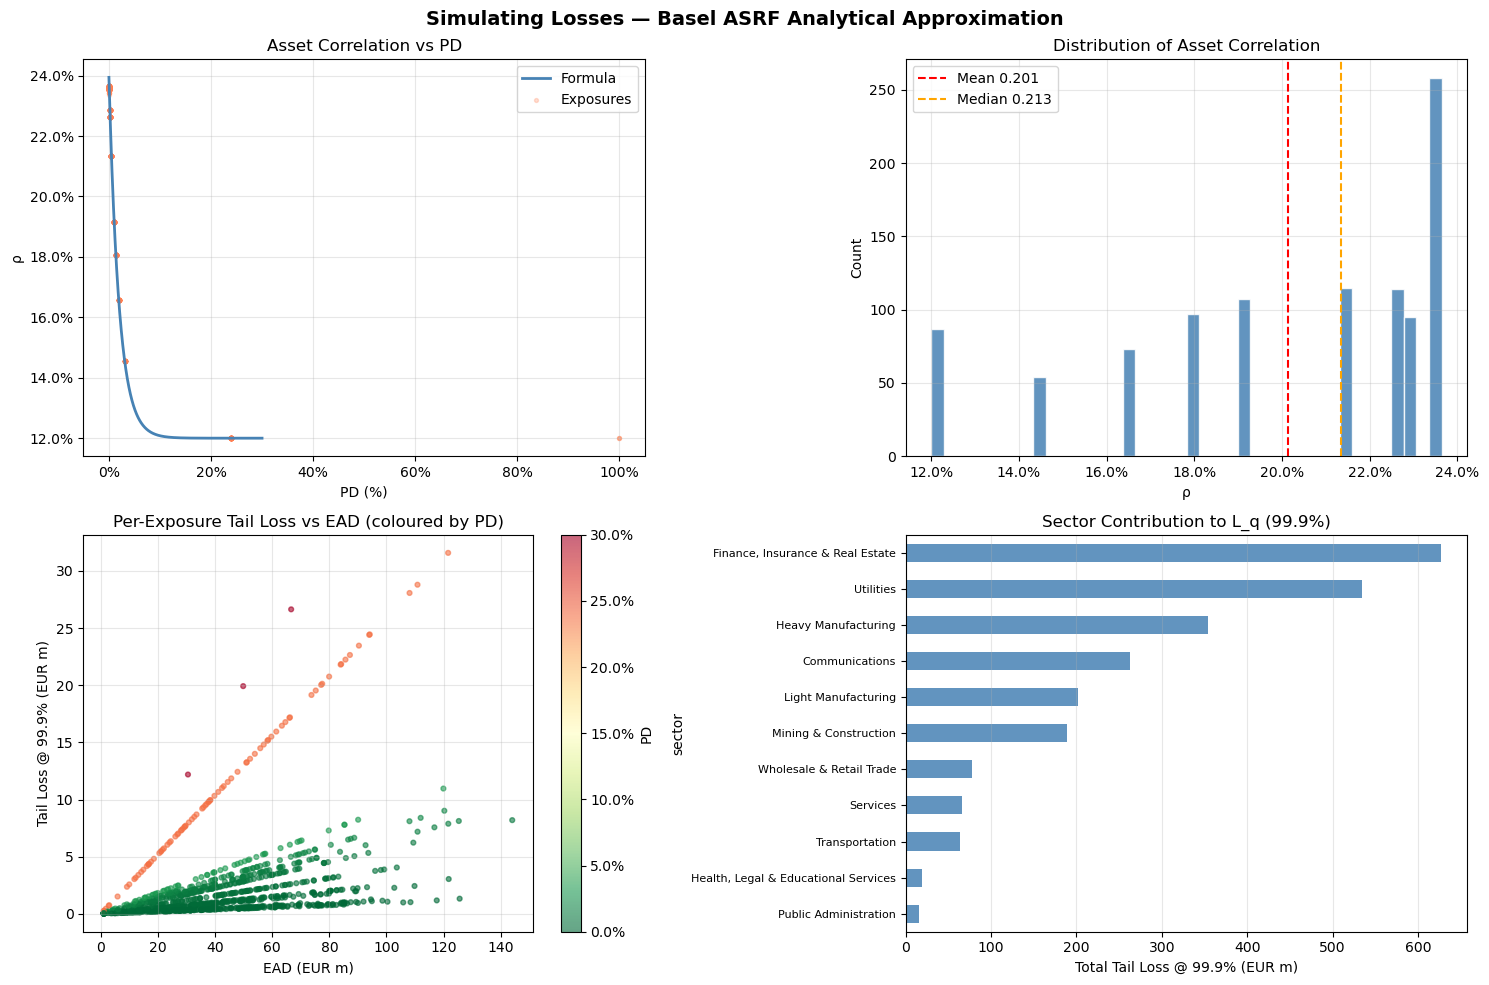

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Simulating Losses — Basel ASRF Analytical Approximation', fontsize=14, fontweight='bold')

# ── 1. ρ vs PD (theoretical + scatter) ───────────────────────────────────────
ax = axes[0, 0]
pd_range = np.linspace(0.0001, 0.30, 500)
ax.plot(pd_range * 100, asset_correlation_formula(pd_range), color='steelblue', lw=2, label='Formula')
ax.scatter(df['pd'] * 100, df['asset_correlation'], alpha=0.25, s=8, color='coral', label='Exposures')
ax.set_xlabel('PD (%)')
ax.set_ylabel('ρ')
ax.set_title('Asset Correlation vs PD')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()
ax.grid(True, alpha=0.3)

# ── 2. Distribution of ρ ─────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(df['asset_correlation'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['asset_correlation'].mean(), color='red',    linestyle='--', label=f"Mean {df['asset_correlation'].mean():.3f}")
ax.axvline(df['asset_correlation'].median(), color='orange', linestyle='--', label=f"Median {df['asset_correlation'].median():.3f}")
ax.set_xlabel('ρ')
ax.set_ylabel('Count')
ax.set_title('Distribution of Asset Correlation')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()
ax.grid(True, alpha=0.3)

# ── 3. Individual loss_999 vs EAD ────────────────────────────────────────────
ax = axes[1, 0]
scatter = ax.scatter(
    df['ead_eur_m'], df['loss_999pct'],
    c=df['pd'], cmap='RdYlGn_r', s=12, alpha=0.6, vmin=0, vmax=0.3
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('PD')
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('EAD (EUR m)')
ax.set_ylabel('Tail Loss @ 99.9% (EUR m)')
ax.set_title('Per-Exposure Tail Loss vs EAD (coloured by PD)')
ax.grid(True, alpha=0.3)

# ── 4. Sector breakdown of L_q (99.9%) ───────────────────────────────────────
ax = axes[1, 1]
sector_loss = df.groupby('sector')['loss_999pct'].sum().sort_values()
sector_loss.plot.barh(ax=ax, color='steelblue', alpha=0.85)
ax.set_xlabel('Total Tail Loss @ 99.9% (EUR m)')
ax.set_title('Sector Contribution to L_q (99.9%)')
ax.tick_params(axis='y', labelsize=8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('simulating_losses_charts.png', dpi=150, bbox_inches='tight')
plt.show()

## Export

In [8]:
out_path = 'data/portfolio_simulation_with_losses.csv'
df.to_csv(out_path, index=False)
print(f'Saved {len(df):,} rows → {out_path}')
print(f'Columns: {list(df.columns)}')

Saved 1,000 rows → data/portfolio_simulation_with_losses.csv
Columns: ['exposure_id', 'sector', 'sic_range', 'rating', 'pd', 'ead_eur_m', 'asset_correlation', 'loss_99pct', 'loss_999pct', 'loss_9997pct']
